# 🎯 Detector de PPE con YOLOv8
> **Curso:** Inteligencia Artificial Avanzada — UNAB Digital

> ⚠️ **ANTES DE EMPEZAR:** Activa la GPU en Colab:  
> `Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU T4`


## PASO 1 — Verificar GPU

In [1]:
import torch

print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ No se detectó GPU. Ve a Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU")

CUDA disponible: True
✅ GPU: Tesla T4
💾 Memoria GPU: 15.6 GB



## PASO 2 — Instalar dependencias

In [2]:
!pip install ultralytics roboflow --quiet

import os, cv2, shutil, torch
from ultralytics import YOLO
from IPython.display import Image, display

print("✅ Librerías instaladas e importadas correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Librerías instaladas e importadas correctamente



## PASO 3 — Conectar Google Drive y copiar dataset

> El dataset ya está guardado en tu Google Drive en la carpeta `Mi unidad/ppe/ppe-factory-1`

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

src = '/content/drive/MyDrive/ppe/ppe-factory-1'
dst = '/content/dataset'

if not os.path.exists(dst):
    print("⏳ Copiando dataset desde Drive... (puede tardar unos minutos)")
    shutil.copytree(src, dst)
    print("✅ Dataset copiado correctamente")
else:
    print("✅ Dataset ya existe en /content/dataset")

Mounted at /content/drive
⏳ Copiando dataset desde Drive... (puede tardar unos minutos)
✅ Dataset copiado correctamente



## PASO 4 — Verificar estructura del dataset

In [4]:
import os

BASE_PATH = '/content/dataset'
subdirs = ['train/images', 'train/labels', 'valid/images', 'valid/labels', 'test/images', 'test/labels']

print('📂 Verificación de estructura del dataset:')
print('-' * 55)
all_ok = True
for subdir in subdirs:
    full_path = os.path.join(BASE_PATH, subdir)
    if not os.path.exists(full_path):
        print(f'🚨 ERROR: No existe → {full_path}')
        all_ok = False
    else:
        n = len(os.listdir(full_path))
        print(f'✅ {subdir:<25} — {n:>4} archivos')

print('-' * 55)
if all_ok:
    print('✅ Estructura del dataset correcta')
else:
    print('⚠️ Hay carpetas faltantes. Verifica tu Drive.')

# Mostrar contenido del data.yaml
yaml_path = '/content/dataset/data.yaml'
if os.path.exists(yaml_path):
    print('\n📄 Contenido de data.yaml:')
    print('-' * 40)
    with open(yaml_path, 'r') as f:
        print(f.read())
else:
    print('⚠️ No se encontró data.yaml')

📂 Verificación de estructura del dataset:
-------------------------------------------------------
✅ train/images              — 4890 archivos
✅ train/labels              — 4689 archivos
✅ valid/images              —  371 archivos
✅ valid/labels              —    0 archivos
✅ test/images               —  143 archivos
✅ test/labels               —    0 archivos
-------------------------------------------------------
✅ Estructura del dataset correcta
⚠️ No se encontró data.yaml


In [7]:
import os

# Buscar data.yaml en todo el dataset
print("🔍 Buscando data.yaml...")
for root, dirs, files in os.walk('/content/dataset'):
    for file in files:
        if file.endswith('.yaml') or file.endswith('.zip'):
            print(f"  Encontrado: {os.path.join(root, file)}")

# Listar todo lo que hay en /content/dataset
print("\n📂 Contenido de /content/dataset:")
for item in os.listdir('/content/dataset'):
    print(f"  - {item}")

🔍 Buscando data.yaml...
  Encontrado: /content/dataset/roboflow.zip

📂 Contenido de /content/dataset:
  - roboflow.zip
  - train
  - valid
  - test


In [8]:
import zipfile, os

zip_path = '/content/dataset/roboflow.zip'
extract_path = '/content/dataset'

print("⏳ Extrayendo roboflow.zip...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("✅ Extraído correctamente")

# Verificar si ya aparece el data.yaml
print("\n🔍 Buscando data.yaml...")
for root, dirs, files in os.walk('/content/dataset'):
    for file in files:
        if file.endswith('.yaml'):
            print(f"  ✅ Encontrado: {os.path.join(root, file)}")

⏳ Extrayendo roboflow.zip...
✅ Extraído correctamente

🔍 Buscando data.yaml...
  ✅ Encontrado: /content/dataset/data.yaml



## PASO 5 — Entrenar el modelo

>

In [9]:
from ultralytics import YOLO

# Cargar modelo base preentrenado
model = YOLO('yolov8n.pt')
print('✅ Modelo base YOLOv8n cargado')
model.info()

✅ Modelo base YOLOv8n cargado
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [10]:
# Entrenar el modelo
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=416,
    batch=16,
    project='/content/runs',
    name='ppe_detector',
    save=True,
    patience=100,
    verbose=True
)

print('\n✅ Entrenamiento completado!')
print('📁 Modelo guardado en: /content/runs/ppe_detector/weights/best.pt')

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_detector-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

---
## PASO 6 — Ver curvas de entrenamiento

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/runs/ppe_detector-2

📈 results.png


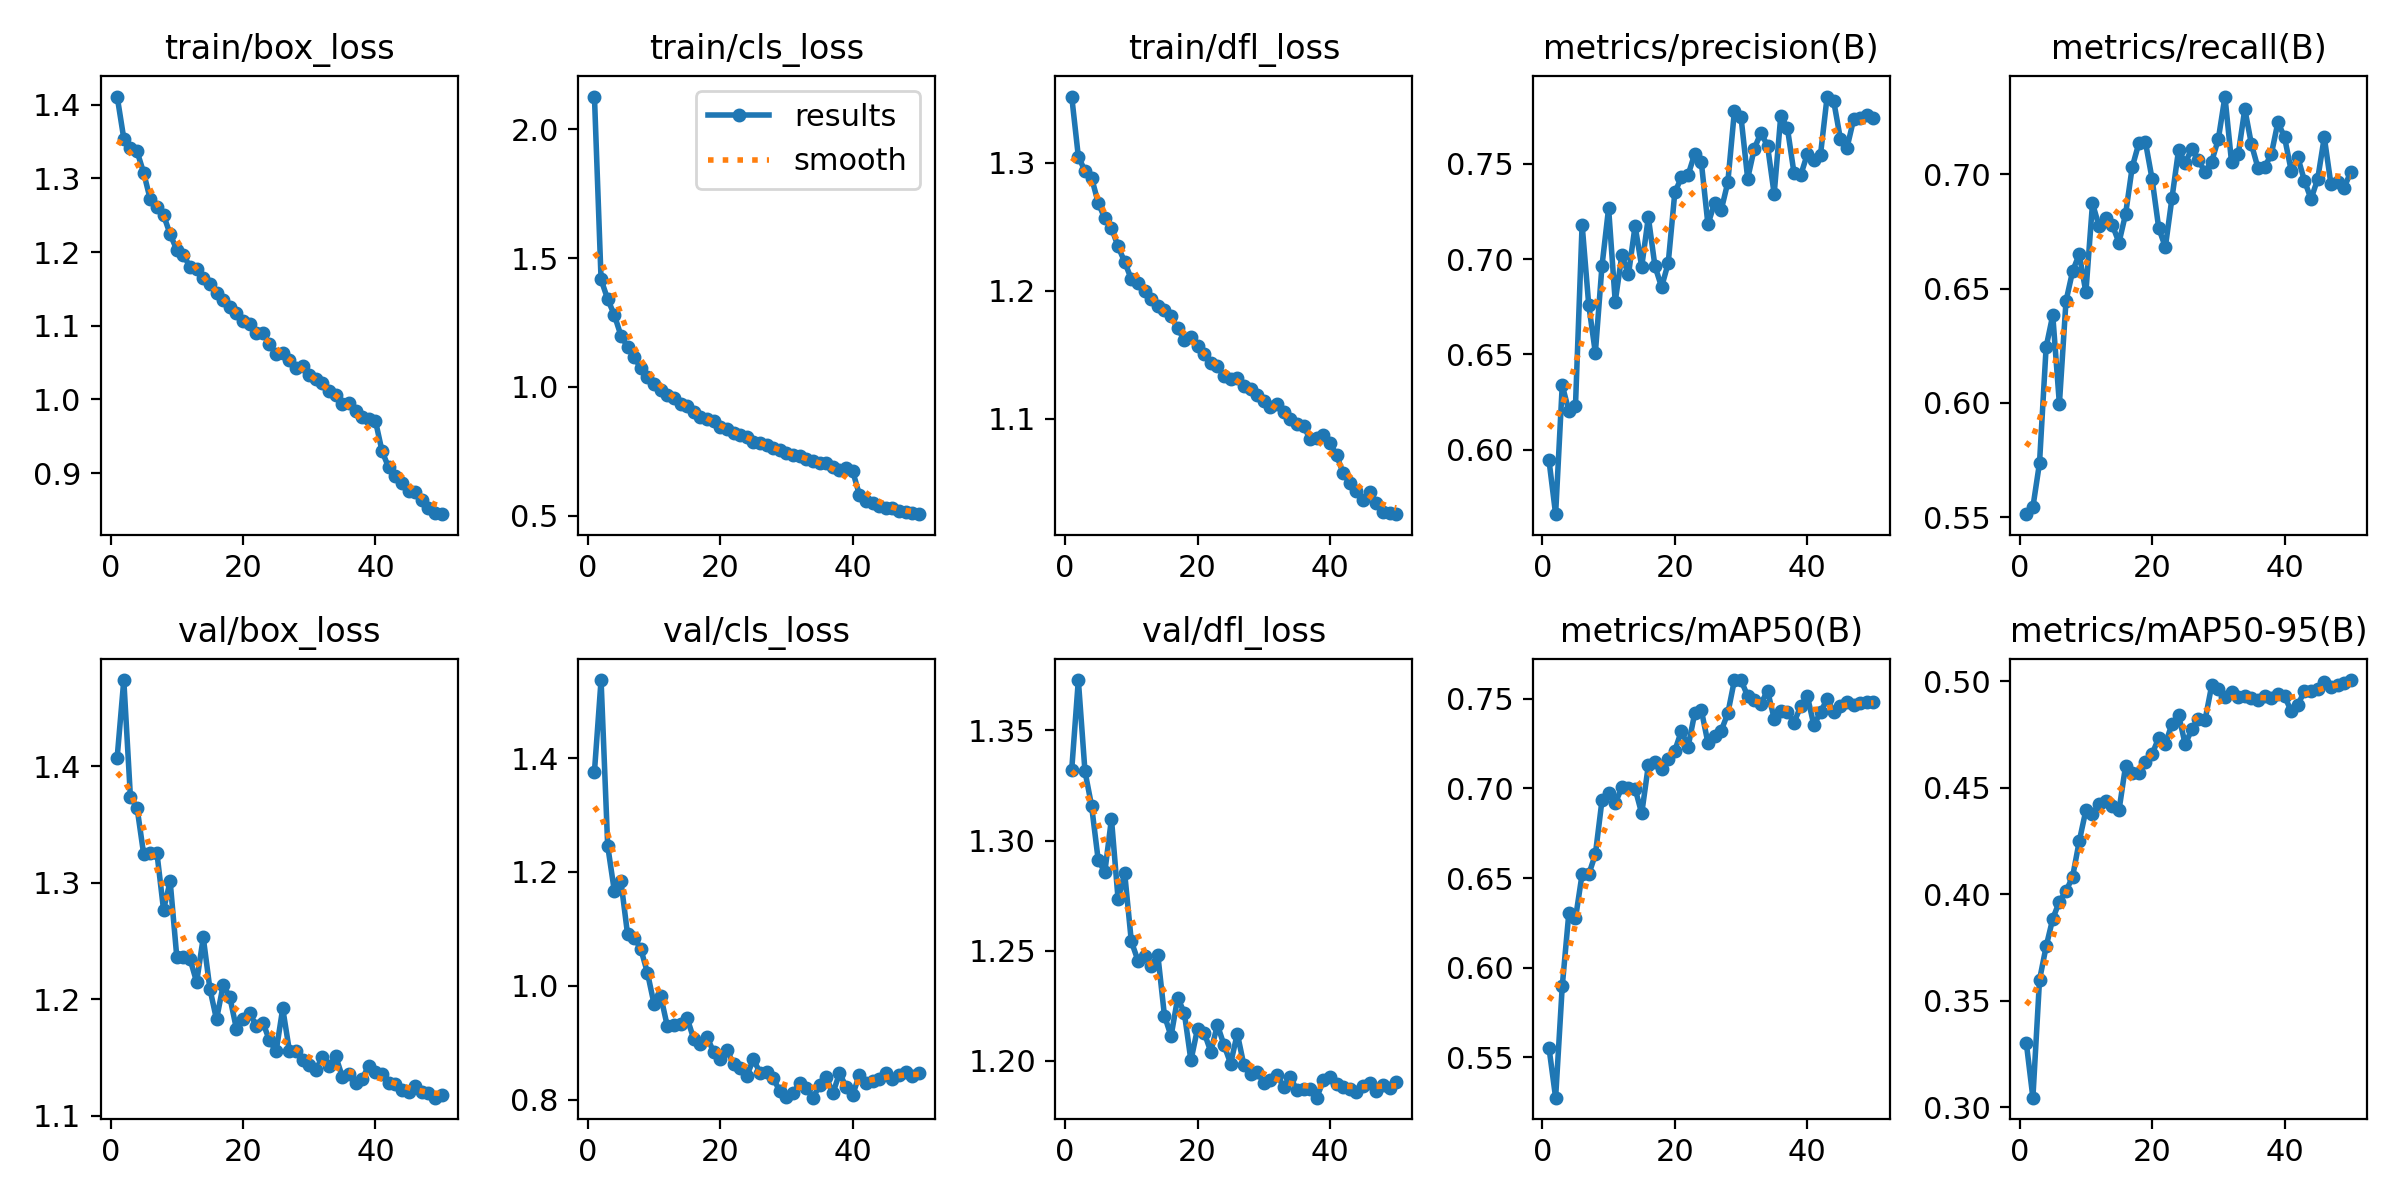

📈 confusion_matrix.png


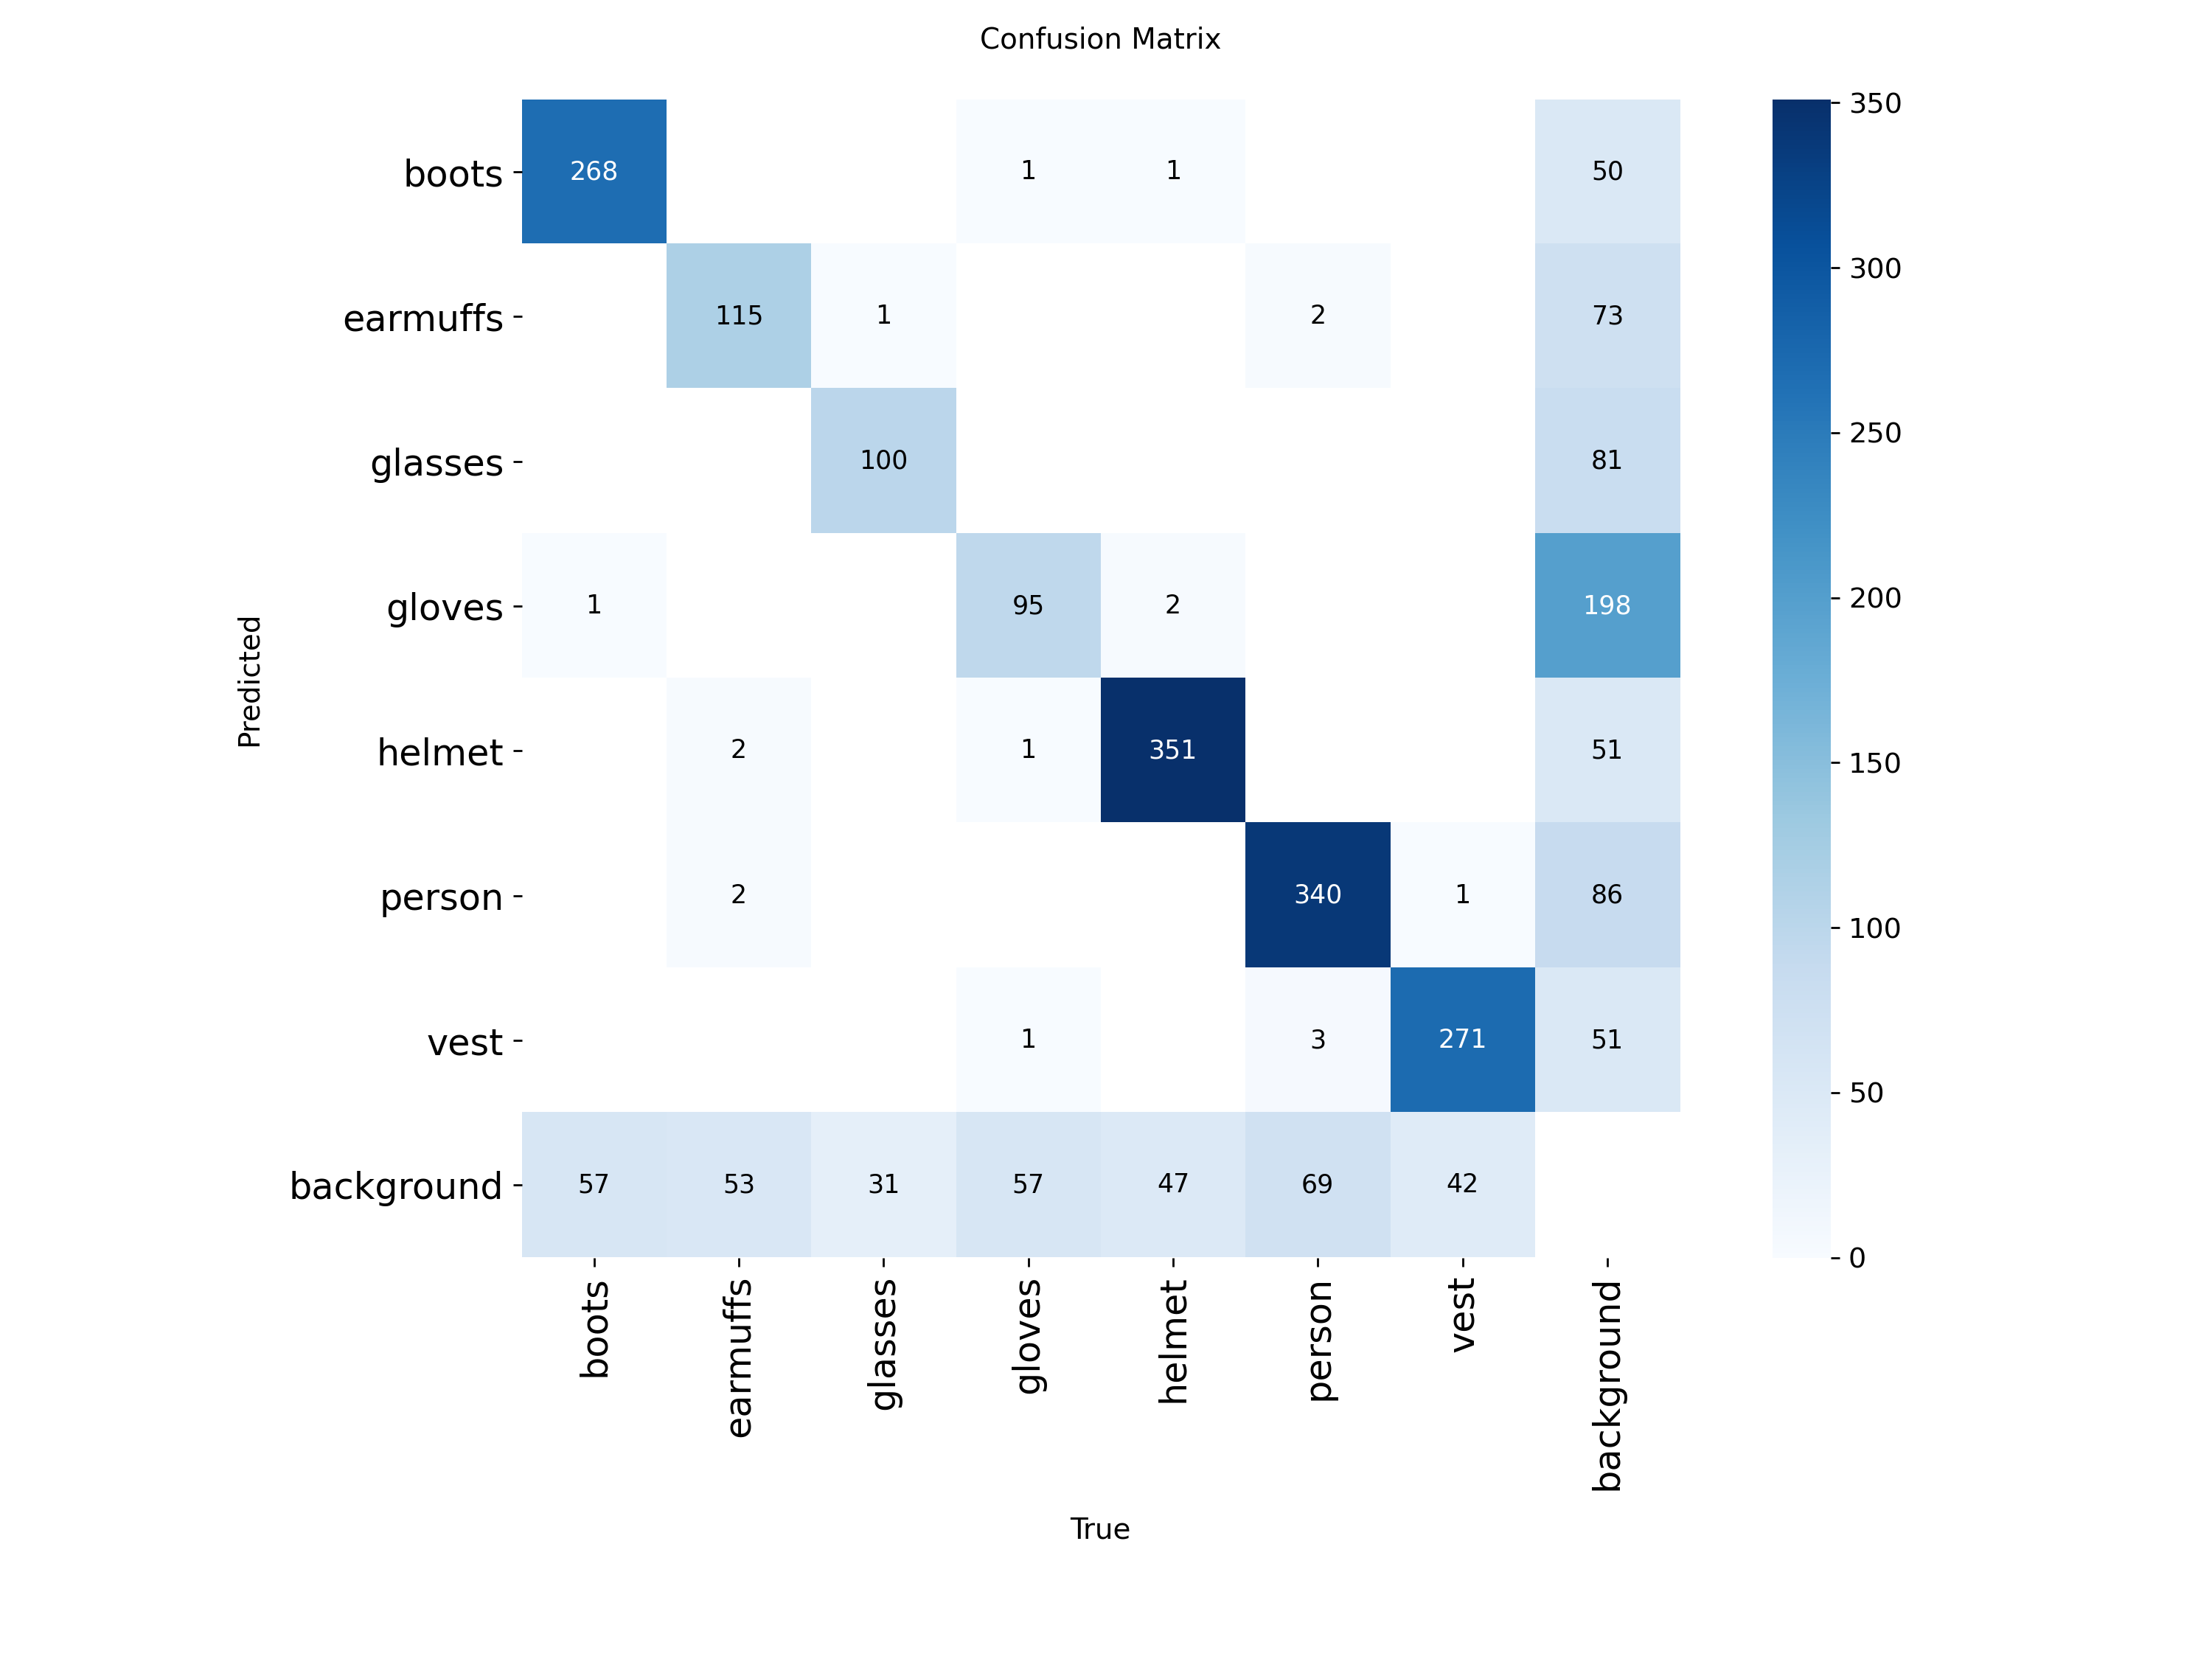

ℹ️ F1_curve.png no encontrado aún
ℹ️ PR_curve.png no encontrado aún


In [12]:
import os
from IPython.display import Image, display

train_dir = '/content/runs/ppe_detector-2'

for plot_name in ['results.png', 'confusion_matrix.png', 'F1_curve.png', 'PR_curve.png']:
    plot_path = os.path.join(train_dir, plot_name)
    if os.path.exists(plot_path):
        print(f'📈 {plot_name}')
        display(Image(filename=plot_path, width=700))
    else:
        print(f'ℹ️ {plot_name} no encontrado aún')

---
## PASO 7 — Evaluar el modelo

In [14]:
from ultralytics import YOLO

model = YOLO('/content/runs/ppe_detector-2/weights/best.pt')
print('✅ Modelo best.pt cargado')

metrics = model.val(data='/content/dataset/data.yaml')

print('\n📊 Resultados de evaluación:')
print(f'  mAP50:    {metrics.box.map50:.3f}')
print(f'  mAP50-95: {metrics.box.map:.3f}')

✅ Modelo best.pt cargado
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1418.5±491.7 MB/s, size: 46.1 KB)
val: Scanning /content/dataset/valid/labels.cache... 371 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 371/371 141.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.9it/s 6.1s
                   all        371       1914       0.78      0.698      0.747        0.5
                 boots        144        326      0.912      0.764      0.854      0.596
              earmuffs        109        172      0.696      0.558      0.607      0.385
               glasses        111        132      0.776      0.629      0.728      0.378
                gloves         75        155      0.385      0.503      0.384      0.212
                helmet 

---
## PASO 8 — Probar el modelo con imágenes

🖼️ Imagen de prueba: /content/dataset/test/images/images11_jpg.rf.70106d89164a5c1e6dfeeb69b6877cca.jpg

image 1/1 /content/dataset/test/images/images11_jpg.rf.70106d89164a5c1e6dfeeb69b6877cca.jpg: 416x416 2 earmuffss, 7.4ms
Speed: 2.1ms preprocess, 7.4ms inference, 1.9ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/prueba_individual


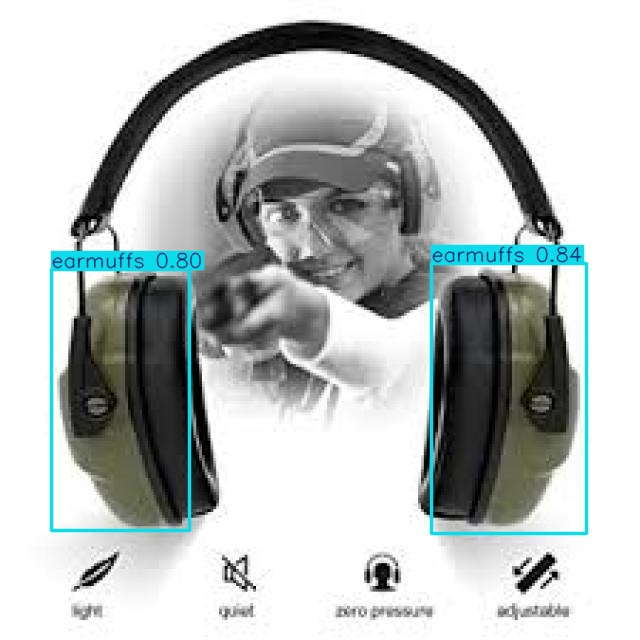


✅ Detecciones encontradas: 2


In [15]:
# Predicción en una imagen de prueba
import glob
from IPython.display import Image, display

test_images = glob.glob('/content/dataset/test/images/*.jpg')

if test_images:
    test_img = test_images[0]
    print(f'🖼️ Imagen de prueba: {test_img}')

    results = model.predict(
        source=test_img,
        conf=0.25,
        save=True,
        project='/content/runs',
        name='prueba_individual'
    )

    saved_img = os.path.join(results[0].save_dir, os.path.basename(test_img))
    if os.path.exists(saved_img):
        display(Image(filename=saved_img, width=700))

    print(f'\n✅ Detecciones encontradas: {len(results[0].boxes)}')
else:
    print('⚠️ No se encontraron imágenes de prueba')

In [16]:
# Predicción en TODAS las imágenes de test
import os

test_images_dir = '/content/dataset/test/images'
all_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f'🔍 Procesando {len(all_images)} imágenes de test...')
print('-' * 50)

for i, filename in enumerate(all_images):
    image_path = os.path.join(test_images_dir, filename)
    results = model.predict(image_path, save=True, imgsz=640, conf=0.25, verbose=False)
    n_detections = len(results[0].boxes)
    print(f'[{i+1:03d}/{len(all_images)}] {filename:<50} → {n_detections} detecciones')

print('-' * 50)
print('✅ Predicciones completadas. Resultados en /content/runs/')

🔍 Procesando 143 imágenes de test...
--------------------------------------------------
Results saved to /content/runs/prueba_individual
[001/143] images11_jpg.rf.70106d89164a5c1e6dfeeb69b6877cca.jpg → 5 detecciones
Results saved to /content/runs/prueba_individual
[002/143] Video4_273_jpg.rf.34a44a8eaa162511f9174c8e693d4457.jpg → 7 detecciones
Results saved to /content/runs/prueba_individual
[003/143] 20220621_132901_jpg.rf.3a9cffc3f9ca94e3f48d41195b683807.jpg → 5 detecciones
Results saved to /content/runs/prueba_individual
[004/143] image_245_jpg.rf.c2812eafe2470f6719e0024cb9fe6f25.jpg → 6 detecciones
Results saved to /content/runs/prueba_individual
[005/143] image_289_jpg.rf.7ef6c5310f27e90a798be4f6d746424c.jpg → 5 detecciones
Results saved to /content/runs/prueba_individual
[006/143] gozluk_075_jpg.rf.0107720870e60c93ccc9cdf9c6531ad5.jpg → 3 detecciones
Results saved to /content/runs/prueba_individual
[007/143] Video3_166_jpg.rf.9a30aba572e0738092ad4c73502de4d5.jpg → 6 detecciones
R

---
## PASO 9 — Exportar el modelo

In [17]:
import os

export_dir = '/content/modelos_exportados'
os.makedirs(export_dir, exist_ok=True)

# Exportar a ONNX
print('⏳ Exportando a ONNX...')
model.export(format='onnx', opset=12)
print('✅ Exportado a ONNX')

# Exportar a TorchScript
print('⏳ Exportando a TorchScript...')
model.export(format='torchscript')
print('✅ Exportado a TorchScript')

# Exportar a TFLite
print('⏳ Exportando a TFLite...')
model.export(format='tflite')
print('✅ Exportado a TFLite')

⏳ Exportando a ONNX...
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/ppe_detector-2/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 11, 3549) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 309ms
Prepared 4 packages in 4.14s
Installed 4 packages in 313ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 5.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 6.8s

In [18]:
# Copiar modelos a carpeta de exportación
import shutil, os

weights_dir = '/content/runs/ppe_detector-2/weights'
export_dir = '/content/modelos_exportados'

def get_dir_size(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.exists(fp):
                total += os.path.getsize(fp)
    return total

if os.path.exists(weights_dir):
    for f in os.listdir(weights_dir):
        src_path = os.path.join(weights_dir, f)
        dst_path = os.path.join(export_dir, f)
        if os.path.isfile(src_path):
            shutil.copy2(src_path, dst_path)
        elif os.path.isdir(src_path):
            if os.path.exists(dst_path):
                shutil.rmtree(dst_path)
            shutil.copytree(src_path, dst_path)

    print('📦 Archivos en carpeta de exportación:')
    for f in os.listdir(export_dir):
        item_path = os.path.join(export_dir, f)
        size = os.path.getsize(item_path) / 1e6 if os.path.isfile(item_path) else get_dir_size(item_path) / 1e6
        tipo = '' if os.path.isfile(item_path) else '(Directorio)'
        print(f'  {f:<40} {size:.1f} MB {tipo}')
else:
    print('⚠️ Completa el entrenamiento primero.')

📦 Archivos en carpeta de exportación:
  last.pt                                  6.2 MB 
  best.onnx                                12.2 MB 
  best_saved_model                         30.6 MB (Directorio)
  best.pt                                  6.2 MB 
  best.torchscript                         12.4 MB 


---
## PASO 10 — Descargar el modelo al PC

> Guarda el archivo `best.pt` en tu proyecto de VS Code para usarlo en la app Streamlit

In [19]:
# Descargar best.pt
from google.colab import files
import os

model_path = '/content/runs/ppe_detector-2/weights/best.pt'

if os.path.exists(model_path):
    print('⏳ Descargando best.pt...')
    files.download(model_path)
    print('✅ Descarga iniciada')
else:
    print('❌ No se encontró best.pt. Completa el entrenamiento primero.')

⏳ Descargando best.pt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga iniciada


In [20]:
# Descargar todos los modelos como ZIP
from google.colab import files
import shutil

zip_path = '/content/modelos_ppe'
print('⏳ Comprimiendo modelos...')
shutil.make_archive(zip_path, 'zip', '/content/modelos_exportados')
print('✅ Descargando ZIP...')
files.download(f'{zip_path}.zip')

⏳ Comprimiendo modelos...
✅ Descargando ZIP...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>